In [3]:
import numpy as np
import matplotlib.pyplot as plt

class TrafficModelingProject:
    def __init__(self, N=20, Max_Speed=30.0, alpha_Critique=10.0, alpha_V=15.0,
                 alpha_inf=20.0, alpha_Initial=5.0, Time=20.0, tau=0.2):
        self.N = N
        self.Max_Speed = Max_Speed
        self.alpha_Critique = alpha_Critique
        self.alpha_V = alpha_V
        self.alpha_inf = alpha_inf
        self.alpha_Initial = alpha_Initial
        self.Time = Time
        self.tau = tau

        self.K = int(self.Time / self.tau)
        self.time = np.linspace(0, self.Time, self.K)

    def F_OV(self, alpha):
        alpha = np.asarray(alpha)
        res = np.zeros_like(alpha, dtype=float)
        inter = alpha > self.alpha_Critique
        res[inter] = 1 - np.exp(-(alpha[inter] - self.alpha_Critique) / (self.alpha_V - self.alpha_Critique))
        return res

    def simulate(self, method='OV', noise_std=0.0):
        x = np.zeros((self.K, self.N))
        v = np.zeros((self.K, self.N))
        alpha = np.zeros((self.K, self.N))

        for n in range(self.N):
            x[0, n] = (n + 1) * self.alpha_Initial

        for k in range(self.K - 1):
            alpha[k, :-1] = x[k, 1:] - x[k, :-1]
            alpha[k, -1] = self.alpha_inf

            if method == 'OV':
                v_target = self.Max_Speed * self.F_OV(alpha[k, :])
                noise = np.random.normal(0, noise_std, self.N)
                v[k, :] = np.clip(v_target + noise, 0, self.Max_Speed)
                x[k + 1, :] = x[k, :] + self.tau * v[k, :]

            elif method == 'IDM':
                a = 1.5
                b = 1.5
                s0 = 2.0
                T = 1.0

                delta_v = np.zeros(self.N)
                delta_v[:-1] = v[k, :-1] - v[k, 1:]
                delta_v[-1] = 0

                s_star = s0 + v[k, :] * T + (v[k, :] * delta_v) / (2 * np.sqrt(a * b))

                accel = a * (1 - (v[k, :] / self.Max_Speed)**4 - (s_star / np.maximum(alpha[k, :], 0.1))**2)

                noise = np.random.normal(0, noise_std, self.N)
                v[k + 1, :] = np.clip(v[k, :] + self.tau * (accel + noise), 0, self.Max_Speed)
                x[k + 1, :] = x[k, :] + self.tau * v[k + 1, :]

        if method == 'OV':
            alpha[-1, :-1] = x[-1, 1:] - x[-1, :-1]
            alpha[-1, -1] = self.alpha_inf
            v[-1, :] = np.clip(self.Max_Speed * self.F_OV(alpha[-1, :]), 0, self.Max_Speed)

        return x, v, alpha

    def display_plots(self, x, v, alpha, main_title=""):
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 15))
        fig.suptitle(main_title, fontsize=16, fontweight='bold')

        for n in range(self.N):
            ax1.plot(self.time, x[:, n])
        ax1.set_xlabel("Time (s)")
        ax1.set_ylabel("Vehicle Position (m)")
        ax1.set_title("Positions (m)")
        ax1.grid()

        ax2.plot(range(1, self.N + 1), alpha[-1, :], 'o-')
        ax2.set_xlabel("Vehicle n")
        ax2.set_ylabel("Distance (m)")
        ax2.set_title(f"Distances between vehicles after {self.Time}s")
        ax2.grid()

        for n in range(self.N):
            ax3.plot(self.time, v[:, n])
        ax3.set_xlabel("Time (s)")
        ax3.set_ylabel("Speed (m/s)")
        ax3.set_title("Vehicle Speeds")
        ax3.grid()

        plt.tight_layout()
        plt.subplots_adjust(top=0.95)
        plt.show()

Simulating Model 1: OV (Optimal Velocity)...


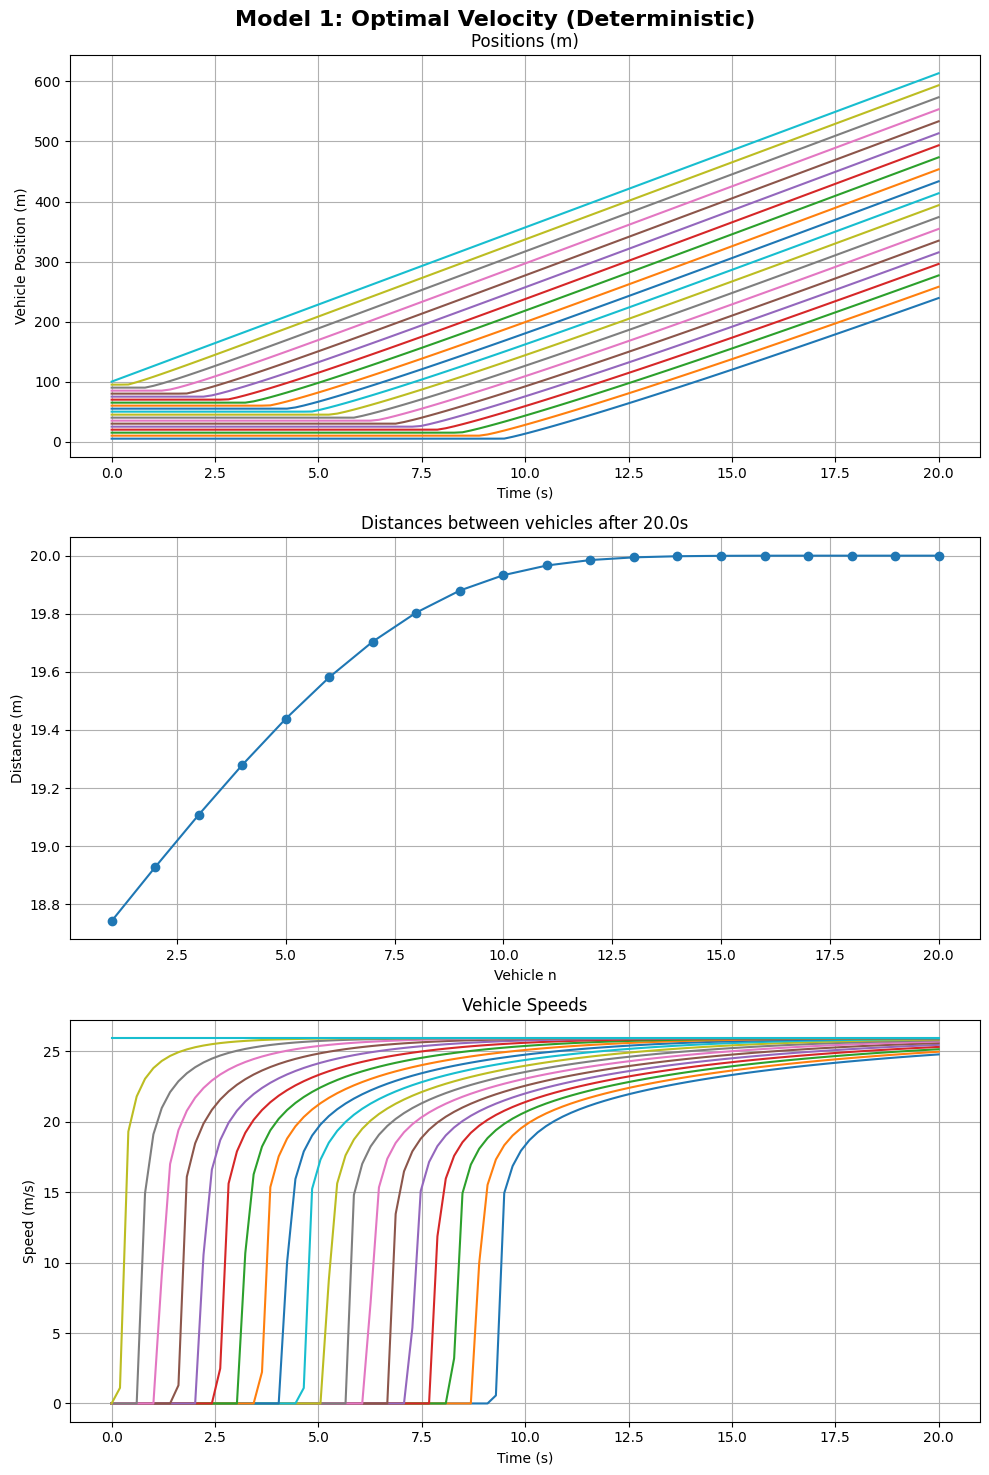

Simulating Model 2: IDM (Intelligent Driver Model) with noise...


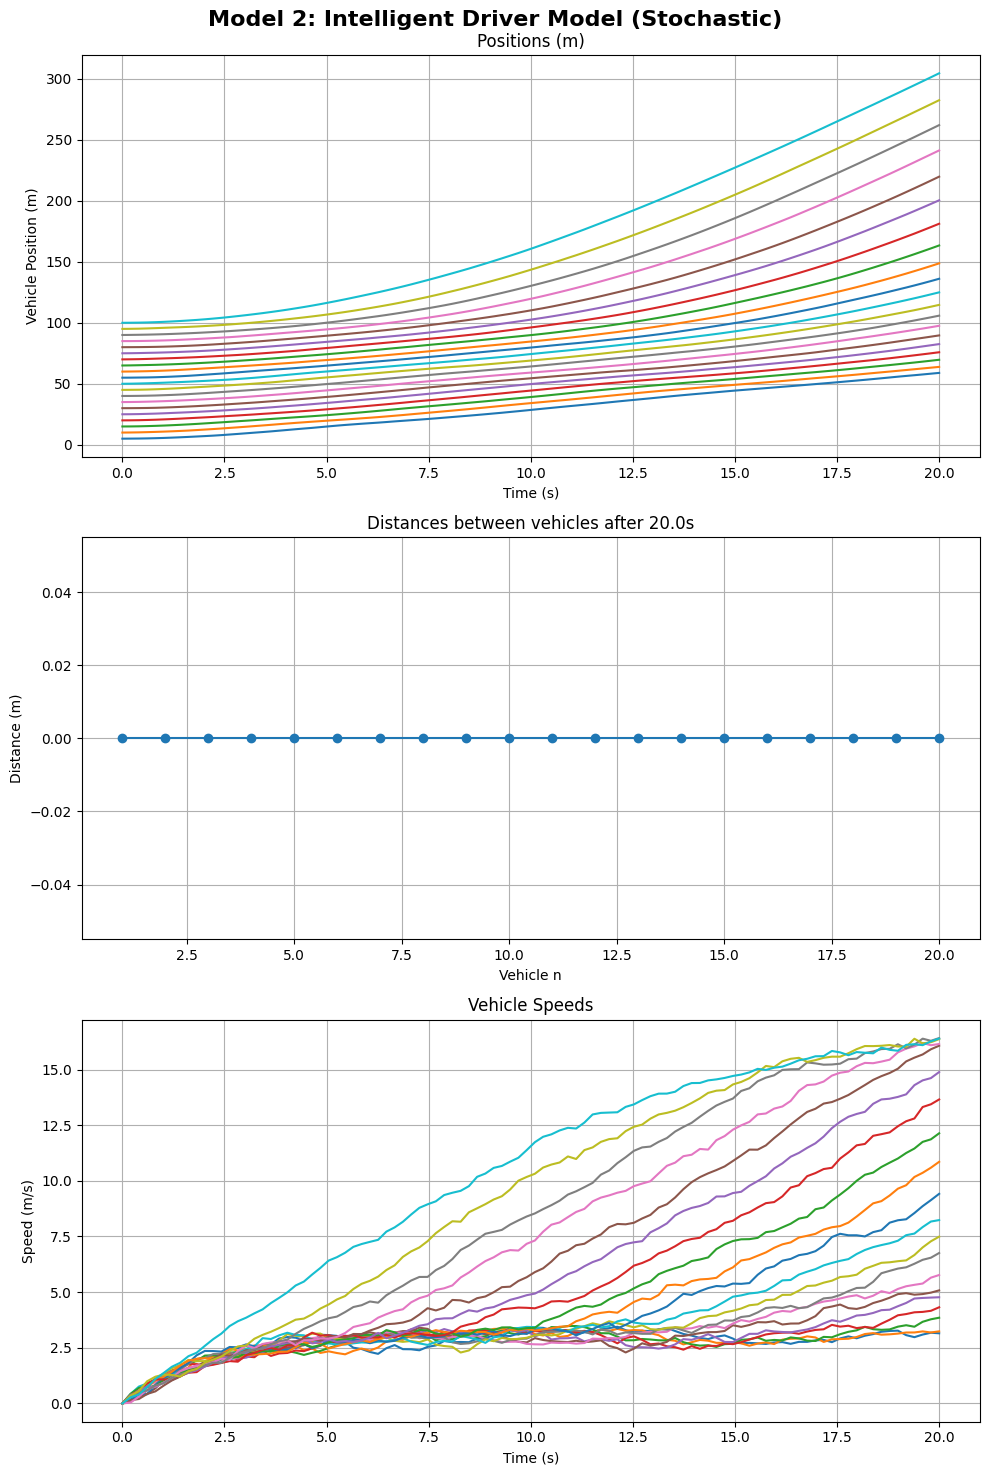

In [4]:
if __name__ == "__main__":
    project = TrafficModelingProject()

    print("Simulating Model 1: OV (Optimal Velocity)...")
    x_ov, v_ov, alpha_ov = project.simulate(method='OV', noise_std=0.0)
    project.display_plots(x_ov, v_ov, alpha_ov, "Model 1: Optimal Velocity (Deterministic)")

    print("Simulating Model 2: IDM (Intelligent Driver Model) with noise...")
    x_idm, v_idm, alpha_idm = project.simulate(method='IDM', noise_std=0.5)
    project.display_plots(x_idm, v_idm, alpha_idm, "Model 2: Intelligent Driver Model (Stochastic)")